In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('D:\\Apy0\\data\\T2M\\ts_T2M_2000_2024_grid_R22_C76.csv')
df_new = pd.DataFrame({
    'date': pd.date_range('2000-01-01', periods=9132, freq='D'),
    'T2M': df['ts_sel_season']
})
df_new.set_index('date', inplace=True)
df_week = df_new.resample('W').mean()
df_week

,T2M
date,
2000-01-02,-14.720368
2000-01-09,-15.693514
2000-01-16,-7.430337
2000-01-23,-6.875218
2000-01-30,-11.724989
...,...
2024-12-08,-5.979645
2024-12-15,-10.923852
2024-12-22,-7.615679


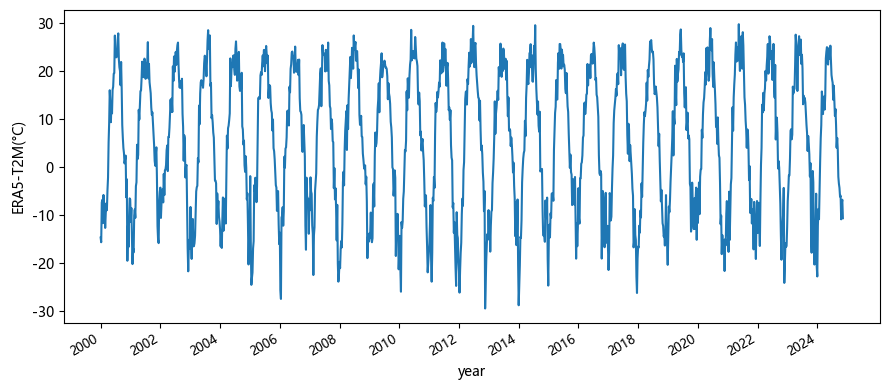

In [3]:
fig, ax = plt.subplots(figsize=(9,4))

ax.plot(np.arange(len(df_week)), df_week['T2M'])
ax.set_xlabel('year')
ax.set_ylabel('ERA5-T2M(°C)')

tick_positions = np.arange(0, len(df_week), 105)
tick_dates = df_week.index[tick_positions]
plt.xticks(ticks=tick_positions, labels=tick_dates, rotation=60, fontsize=9)
tick_labels = tick_dates.strftime('%Y')
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('fig/CH08_F01_peixeiro.png', dpi=300)

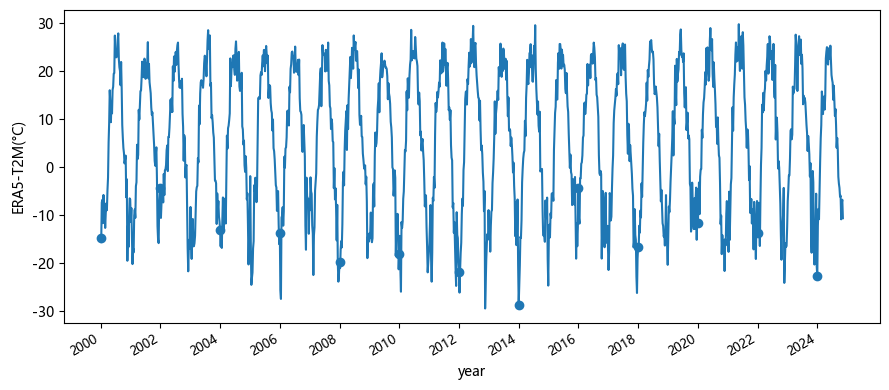

In [4]:
fig, ax = plt.subplots(figsize=(9,4))

ax.plot(np.arange(len(df_week)), df_week['T2M'], markevery=np.arange(0, len(df_week), 105), marker='o')
ax.set_xlabel('year')
ax.set_ylabel('ERA5-T2M(°C)')

tick_positions = np.arange(0, len(df_week), 105)
tick_dates = df_week.index[tick_positions]
plt.xticks(ticks=tick_positions, labels=tick_dates, rotation=60, fontsize=9)
tick_labels = tick_dates.strftime('%Y')
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('fig/CH08_F02_peixeiro.png', dpi=300)

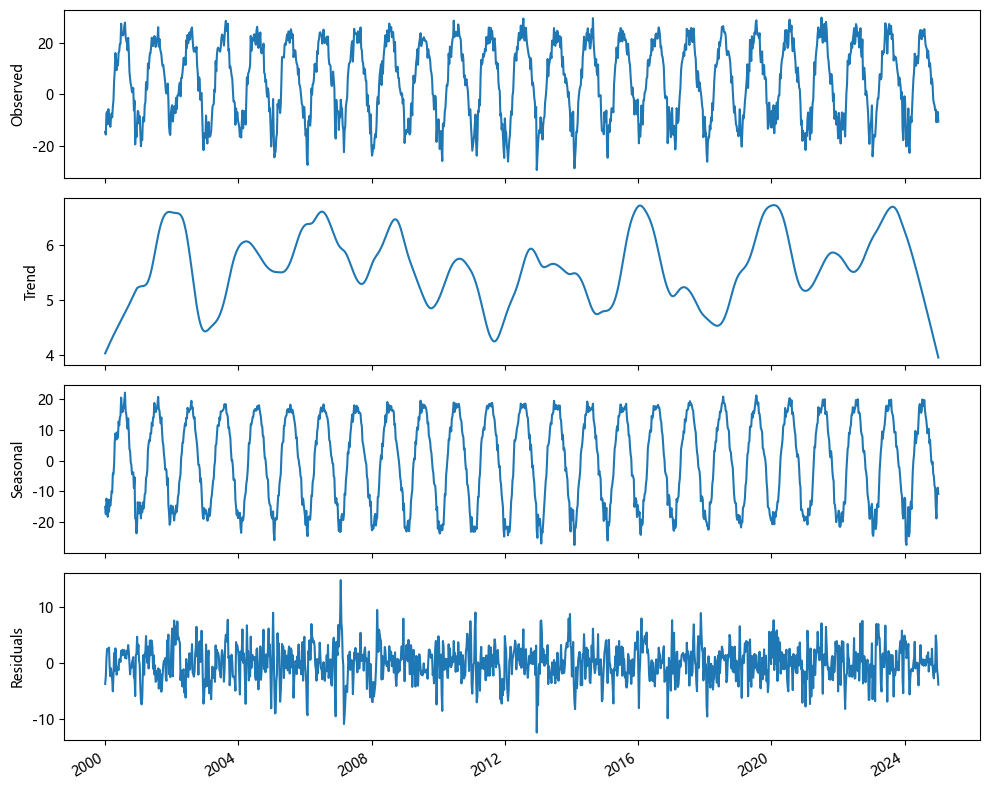

In [5]:
decomposition = STL(df_week['T2M'], period=52).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('fig/CH08_F04_peixeiro.png', dpi=300)

In [6]:
# 平稳性检验
ad_fuller_result = adfuller(df_week['T2M'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -15.091557186376098
p-value: 8.179270354030492e-28


In [7]:
def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(endog, order=(order[0], d, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [8]:
def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(
                endog, 
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [11]:
ps = range(0, 13, 1)
qs = range(0, 13, 1)
Ps = [0]
Qs = [0]

d = 0
D = 0
s = 52

ARIMA_order_list = list(product(ps, qs, Ps, Qs))

train = df_week['T2M'][5:1046]

ARIMA_result_df = optimize_SARIMA(train, ARIMA_order_list, d, D, s)
ARIMA_result_df

100%|██████████| 169/169 [08:04<00:00,  2.87s/it]


,"(p,q,P,Q)",AIC
0,"(5, 1, 0, 0)",14.000000
1,"(4, 12, 0, 0)",34.000000
2,"(4, 6, 0, 0)",5760.578562
3,"(4, 5, 0, 0)",5778.497984
4,"(5, 6, 0, 0)",5781.750685
...,...,...
161,"(0, 4, 0, 0)",6619.955924
162,"(0, 3, 0, 0)",6793.259607
163,"(0, 2, 0, 0)",7110.792101
164,"(0, 1, 0, 0)",7642.371968


In [16]:
ARIMA_model = SARIMAX(train, order=(4,0,12), simple_differencing=False)
ARIMA_model_fit = ARIMA_model.fit(disp=False)

print(ARIMA_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    T2M   No. Observations:                 1041
Model:              SARIMAX(4, 0, 12)   Log Likelihood                   0.000
Date:                Fri, 22 May 2026   AIC                             34.000
Time:                        23:46:28   BIC                            118.115
Sample:                    02-06-2000   HQIC                            65.907
                         - 01-12-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.9819         -0       -inf      0.000       1.982       1.982
ar.L2          0.0012         -0       -inf      0.000       0.001       0.001
ar.L3         -1.9820         -0        inf      0.0

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

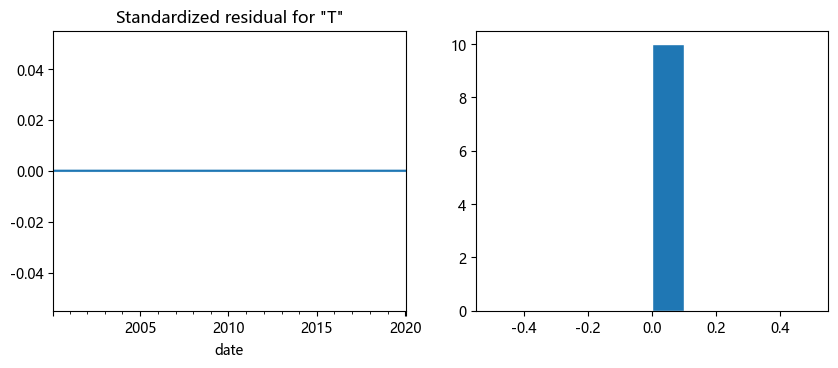

In [17]:
ARIMA_model_fit.plot_diagnostics(figsize=(10,8))

plt.savefig('fig/CH08_F09_peixeiro.png', dpi=300)

In [ ]:
residuals = ARIMA_model_fit.resid

result = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1), return_df=True)

print(result['lb_pvalue'].values)

lb_pvalue


In [15]:
test = df.iloc[-12:]

test['naive_seasonal'] = df['Passengers'].iloc[120:132].values
test

KeyError: 'Passengers'

In [ ]:
ARIMA_pred = ARIMA_model_fit.get_prediction(132, 143).predicted_mean

test['ARIMA_pred'] = ARIMA_pred
test

In [ ]:
SARIMA_model = SARIMAX(train, order=(2,1,1), seasonal_order=(1,1,2,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

In [ ]:
SARIMA_model_fit.plot_diagnostics(figsize=(10,8))

plt.savefig('fig/CH08_F12_peixeiro.png', dpi=300)

In [ ]:
residuals = SARIMA_model_fit.resid

lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(pvalue)

In [ ]:
SARIMA_pred = SARIMA_model_fit.get_prediction(132, 143).predicted_mean

test['SARIMA_pred'] = SARIMA_pred
test

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.plot(test['Passengers'], 'b-', label='actual')
ax.plot(test['naive_seasonal'], 'r:', label='naive seasonal')
ax.plot(test['ARIMA_pred'], 'k--', label='ARIMA(11,2,3)')
ax.plot(test['SARIMA_pred'], 'g-.', label='SARIMA(2,1,1)(1,1,2,12)')

ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')
ax.axvspan(132, 143, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))
ax.set_xlim(120, 143)

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('fig/CH08_F13_peixeiro.png', dpi=300)

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
mape_naive_seasonal = mape(test['Passengers'], test['naive_seasonal'])
mape_ARIMA = mape(test['Passengers'], test['ARIMA_pred'])
mape_SARIMA = mape(test['Passengers'], test['SARIMA_pred'])

print(mape_naive_seasonal, mape_ARIMA, mape_SARIMA)

In [ ]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'ARIMA(11,2,3)', 'SARIMA(2,1,1)(1,1,2,12)']
y = [mape_naive_seasonal, mape_ARIMA, mape_SARIMA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()

plt.savefig('fig/CH08_F14_peixeiro.png', dpi=300)